# 均线交叉策略回测 (MA Crossover Backtest)

数据源: **baostock** (A股免费数据，无需API key) — 与 Zhao 量化研究仓库同类的A股数据。

策略逻辑: 短期均线上穿长期均线(金叉)时买入，下穿(死叉)时卖出；可选 RSI 过滤，避免追高。

回测指标: 总收益、年化收益、夏普比率、最大回撤、胜率、交易次数，并与 Buy&Hold 对比。

In [1]:
import warnings; warnings.filterwarnings('ignore')
import baostock as bs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.sans-serif'] = ['Noto Sans CJK SC', 'WenQuanYi Zen Hei', 'SimHei', 'DejaVu Sans']
mpl.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')
print('环境就绪')

环境就绪


In [2]:
def fetch_ashare(code, start='2020-01-01', end=None):
    """从 baostock 获取A股日线数据, code 如 'sh.600519' 'sz.000001'"""
    lg = bs.login()
    if lg.error_code != '0':
        raise RuntimeError(f'baostock login failed: {lg.error_msg}')
    end = end or pd.Timestamp.today().strftime('%Y-%m-%d')
    rs = bs.query_history_k_data_plus(
        code, 'date,close,volume,amount',
        start_date=start, end_date=end, frequency='d', adjustflag='2')  # 前复权
    rows = []
    while (rs.error_code == '0') and rs.next():
        rows.append(rs.get_row_data())
    bs.logout()
    df = pd.DataFrame(rows, columns=rs.fields)
    for c in ['close', 'volume']:
        df[c] = pd.to_numeric(df[c])
    df['date'] = pd.to_datetime(df['date'])
    return df.set_index('date').sort_index()

In [3]:
def generate_signals(df, fast=10, slow=30, rsi_period=14, rsi_high=70):
    """金叉买入 / 死叉卖出, 可选 RSI 过滤 (RSI>rsi_high 时不追高)"""
    d = df.copy()
    d['ma_fast'] = d['close'].rolling(fast).mean()
    d['ma_slow'] = d['close'].rolling(slow).mean()
    d['diff'] = d['ma_fast'] - d['ma_slow']
    delta = d['close'].diff()
    up = delta.clip(lower=0).rolling(rsi_period).mean()
    down = (-delta.clip(upper=0)).rolling(rsi_period).mean()
    d['rsi'] = 100 - 100 / (1 + up / down)
    # 1=持有, 0=空仓
    d['pos'] = np.where(d['diff'] > 0, 1, 0)
    if rsi_high:
        d['pos'] = np.where((d['diff'] > 0) & (d['rsi'] > rsi_high), 0, d['pos'])
    d['signal'] = d['pos'].diff().fillna(0)  # +1 开仓, -1 平仓
    return d

In [4]:
def backtest(d, initial=100000):
    """按次日开盘成交模拟回测 (避免未来函数)"""
    d = d.copy()
    d['ret'] = d['close'].pct_change()
    d['strategy_ret'] = d['pos'].shift(1) * d['ret']   # 用前一日信号
    d['eq'] = initial * (1 + d['strategy_ret']).cumprod()
    d['bh_eq'] = initial * (1 + d['ret']).cumprod()

    total = d['eq'].iloc[-1] / initial - 1
    bh = d['bh_eq'].iloc[-1] / initial - 1
    years = len(d) / 244
    ann = (1 + total) ** (1 / years) - 1
    daily = d['strategy_ret'].dropna()
    sharpe = daily.mean() / daily.std() * np.sqrt(244) if daily.std() else 0
    dd = (d['eq'] / d['eq'].cummax() - 1).min()

    trades = d['signal'].diff().fillna(0)
    n_trades = int((trades == 1).sum())
    # 每笔交易收益
    entry = d['eq'][trades == 1]
    exit_ = d['eq'][trades == -1]
    if len(entry) > len(exit_):
        exit_ = pd.concat([exit_, pd.Series([d['eq'].iloc[-1]])])
    n = min(len(entry), len(exit_))
    pnl = exit_.values[:n] / entry.values[:n] - 1
    win_rate = (pnl > 0).mean() if len(pnl) else 0

    return d, dict(total=total, annual=ann, sharpe=sharpe, max_dd=dd,
                   trades=n_trades, win_rate=win_rate, bh=bh)

In [5]:
STOCKS = ['sh.600519', 'sz.000001', 'sh.601318', 'sz.300750', 'sh.510300']  # 茅台/平安银行/中国平安/宁德时代/沪深300ETF
NAMES  = ['贵州茅台', '平安银行', '中国平安', '宁德时代', '沪深300ETF']
FAST, SLOW = 10, 30

results, curves = [], {}
for code, name in zip(STOCKS, NAMES):
    df = fetch_ashare(code, start='2021-01-01')
    sig = generate_signals(df, fast=FAST, slow=SLOW)
    d, m = backtest(sig)
    curves[name] = d
    results.append({'股票': name, '总收益': f"{m['total']:.1%}", '年化': f"{m['annual']:.1%}",
                    '夏普': f"{m['sharpe']:.2f}", '最大回撤': f"{m['max_dd']:.1%}",
                    '交易次数': m['trades'], '胜率': f"{m['win_rate']:.0%}",
                    'Buy&Hold': f"{m['bh']:.1%}"})
    print(f"{name}: 完成")

pd.DataFrame(results).set_index('股票')

login success!


logout success!
贵州茅台: 完成


login success!


logout success!
平安银行: 完成


login success!


...

login success!


logout success!
宁德时代: 完成


login success!


logout success!
沪深300ETF: 完成


,总收益,年化,夏普,最大回撤,交易次数,胜率,Buy&Hold
股票,,,,,,,
贵州茅台,-22.0%,-4.4%,-0.25,-32.3%,79,57%,-23.5%
平安银行,-39.3%,-8.5%,-0.55,-49.9%,89,40%,-24.2%
中国平安,13.2%,2.2%,0.22,-22.4%,83,41%,-20.0%
宁德时代,184.7%,20.6%,0.85,-27.5%,107,50%,87.7%
沪深300ETF,-6.3%,-10.0%,-1.00,-7.4%,7,0%,-3.9%


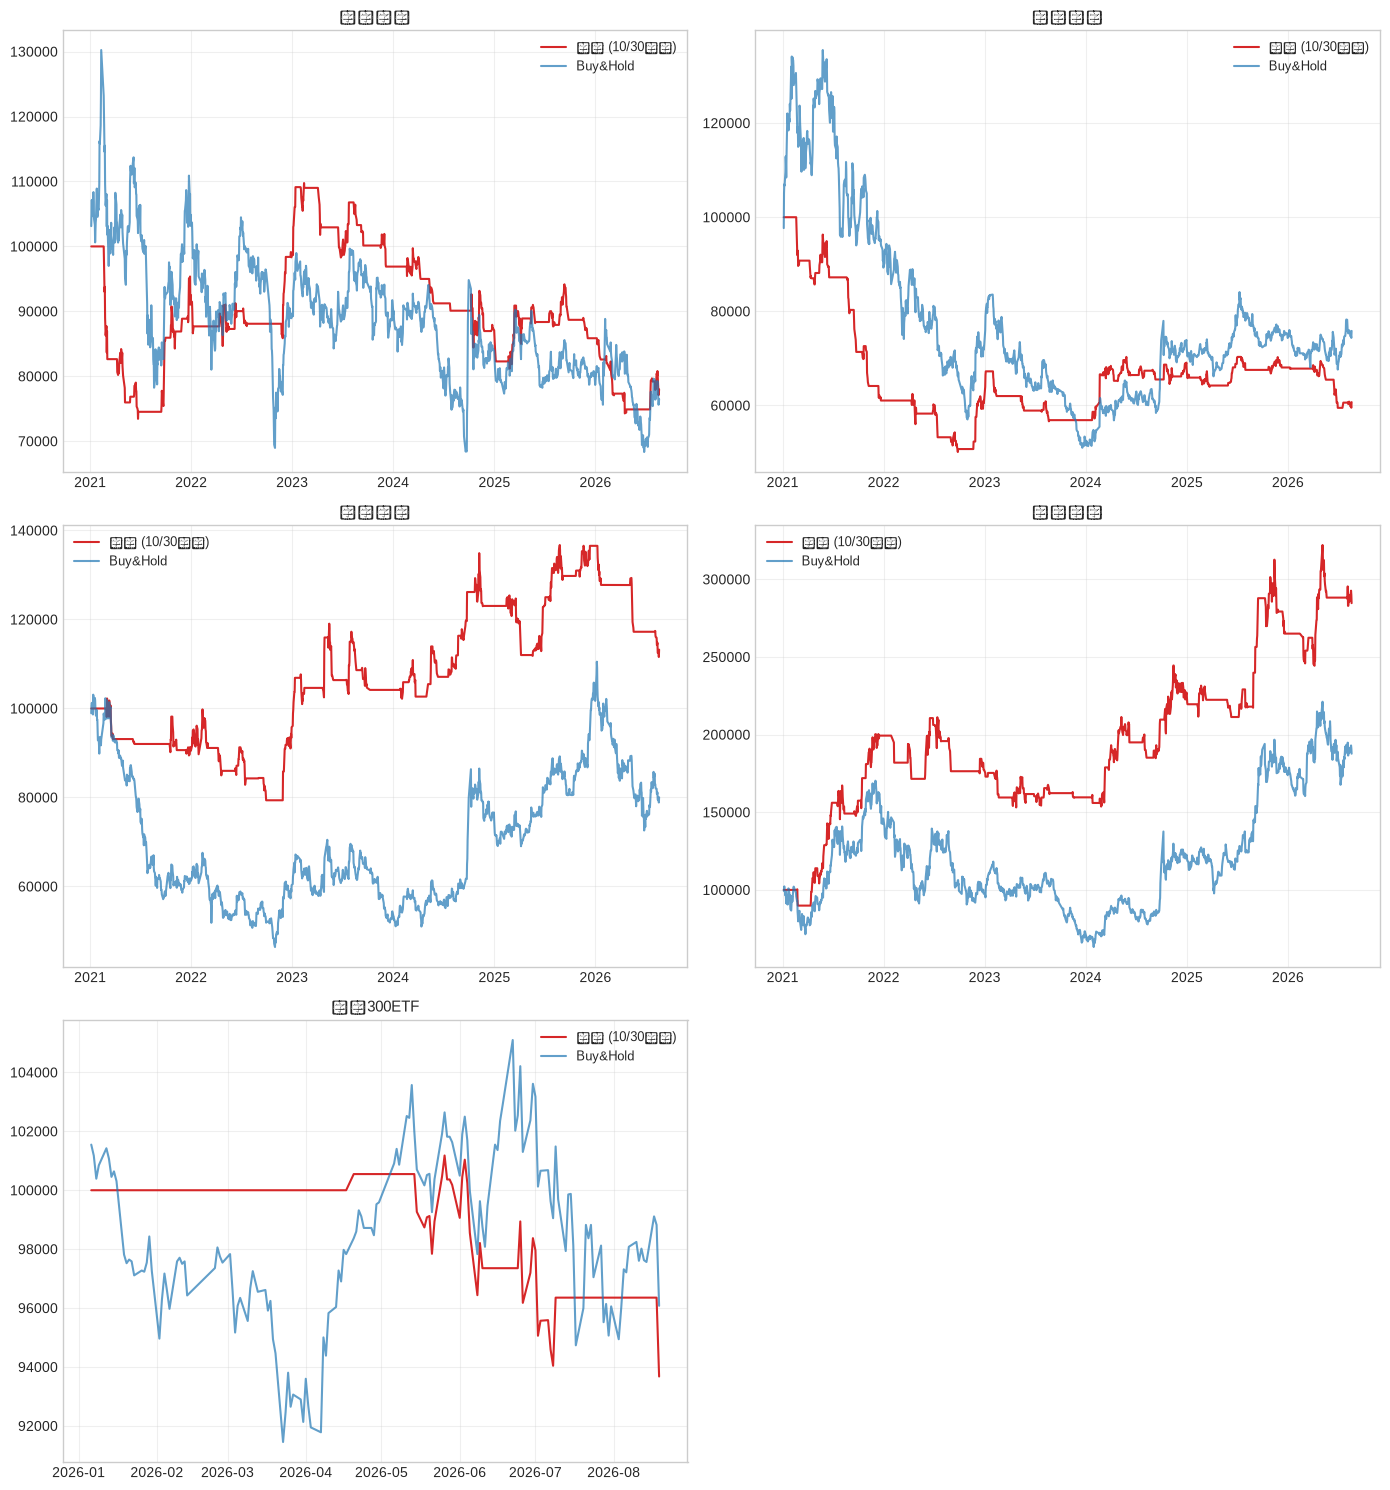

In [6]:
import math
n_plot = len(curves)
cols = 2 if n_plot > 2 else 1
rows = math.ceil(n_plot / cols)
fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows), squeeze=False)
for i, (name, d) in enumerate(curves.items()):
    ax = axes[i // cols][i % cols]
    ax.plot(d.index, d['eq'], label=f'策略 ({FAST}/{SLOW}均线)', color='#d62728')
    ax.plot(d.index, d['bh_eq'], label='Buy&Hold', color='#1f77b4', alpha=0.7)
    ax.set_title(name, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
for i in range(n_plot, rows * cols):
    axes[i // cols][i % cols].axis('off')
plt.tight_layout()
plt.show()

## 怎么玩?

- 换参数: `FAST, SLOW` (如 5/20, 20/60) 或 `rsi_high` (None 可关掉 RSI 过滤)
- 换股票: `STOCKS` 列表加代码, 格式 `sh.`/`sz.` + 代码
- 加条件: 在 `generate_signals` 里加你自己的想法 (成交量放大、北向资金、板块轮动……)
- 更严谨: 加手续费滑点 `d['strategy_ret'] = d['pos'].shift(1) * d['ret'] - 0.0005 * d['signal'].abs().shift(1)`